In [20]:
#imports
import numpy as np
import matplotlib.pyplot as plt
from pyod.utils.data import generate_data
from pyod.models.knn import KNN
from sklearn.metrics import (confusion_matrix, balanced_accuracy_score, roc_curve, auc)

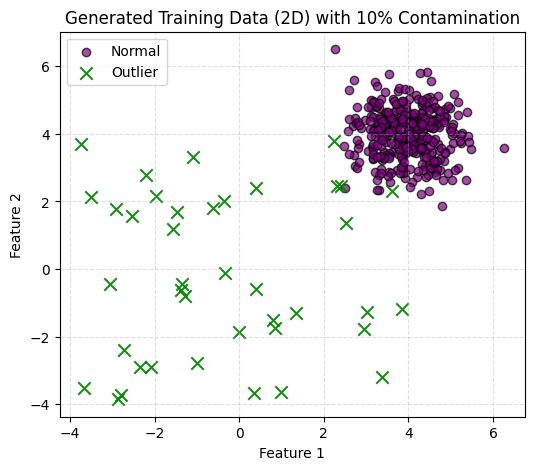

In [24]:
#EX1
train_data, test_data, train_labels, test_labels = generate_data(n_train=400,n_test=100,n_features=2,contamination=0.10,random_state=25)
normal_points = train_data[train_labels == 0]
outlier_points = train_data[train_labels == 1]

plt.figure(figsize=(6, 5))
plt.scatter(normal_points[:, 0], normal_points[:, 1], c='purple', label='Normal', alpha=0.7, edgecolor='k')
plt.scatter(outlier_points[:, 0], outlier_points[:, 1], c='green', label='Outlier', alpha=0.9, marker='x', s=80)
plt.title("Generated Training Data (2D) with 10% Contamination")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Balanced Accuracy (Train): 0.947
Balanced Accuracy (Test):  0.944


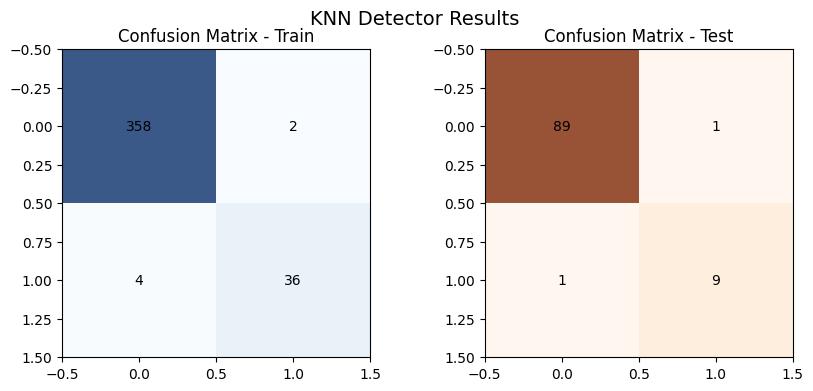

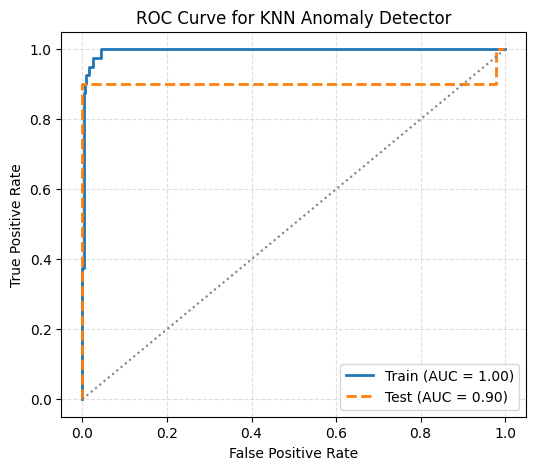

In [22]:
#EX2
detector = KNN(contamination=0.10)
detector.fit(train_data)

train_preds = detector.predict(train_data)
test_preds = detector.predict(test_data)

cm_train = confusion_matrix(train_labels, train_preds)
cm_test = confusion_matrix(test_labels, test_preds)

ba_train = balanced_accuracy_score(train_labels, train_preds)
ba_test = balanced_accuracy_score(test_labels, test_preds)

print(f"Balanced Accuracy (Train): {ba_train:.3f}")
print(f"Balanced Accuracy (Test):  {ba_test:.3f}")

fpr_train, tpr_train, _ = roc_curve(train_labels, detector.decision_function(train_data))
fpr_test, tpr_test, _ = roc_curve(test_labels, detector.decision_function(test_data))
roc_auc_train = auc(fpr_train, tpr_train)
roc_auc_test = auc(fpr_test, tpr_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(cm_train, cmap='Blues', alpha=0.8)
axes[0].set_title("Confusion Matrix - Train")
for (i, j), val in np.ndenumerate(cm_train): axes[0].text(j, i, val, ha='center', va='center', color='black')

axes[1].imshow(cm_test, cmap='Oranges', alpha=0.8)
axes[1].set_title("Confusion Matrix - Test")
for (i, j), val in np.ndenumerate(cm_test): axes[1].text(j, i, val, ha='center', va='center', color='black')

plt.suptitle("KNN Detector Results", fontsize=14)
plt.show()

# ROC Curves for Train and Test
plt.figure(figsize=(6, 5))
plt.plot(fpr_train, tpr_train, label=f"Train (AUC = {roc_auc_train:.2f})", lw=2)
plt.plot(fpr_test, tpr_test, label=f"Test (AUC = {roc_auc_test:.2f})", lw=2, linestyle='--')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for KNN Anomaly Detector")
plt.legend()
plt.grid(alpha=0.4, linestyle='--')
plt.show()

In [23]:
#EX3
train_set, _, labels_train, _ = generate_data(n_train=1000, n_test=0, n_features=1, contamination=0.10, random_state=99)
mean_val = np.mean(train_set)
std_val = np.std(train_set)
z_values = np.abs((train_set - mean_val) / std_val)
cutoff = np.quantile(z_values, 1 - 0.10)
pred_labels = (z_values >= cutoff).astype(int)
score_ba = balanced_accuracy_score(labels_train, pred_labels)

print(f"Z-score threshold: {cutoff:.4f}")
print(f"Balanced Accuracy (1D Z-score Method): {score_ba:.3f}")

Z-score threshold: 1.6482
Balanced Accuracy (1D Z-score Method): 0.622
